![imagen](Wildfire.jpg)

## Introduction

The objective of this notebook is to build and evaluate linear, Ridge, Lasso, and polynomial regression models to estimate the area affected by forest fires, comparing their performance to identify the best predictive approach.

Throughout the analysis, the following tasks will be addressed:

1. Linear regression: Build a standard linear regression model and evaluate its performance on the test set.

2. Ridge regression: Build a Ridge regression model using GridSearchCV to tune the regularization hyperparameter α with the following values: [0.1, 0.5, 1.0]. Use RMSE as the scoring metric.

3. Lasso regression with GridSearch: Build a Lasso regression model using GridSearchCV to tune α with the following values: [1, 2, 3, 4, 5]. Use RMSE as the scoring metric and identify which variables have non-zero coefficients and interpret their importance for the prediction problem.

4. Polynomial regression with validation: Build a polynomial regression model using a validation set to determine the best degree from [2, 3]. Once selected, evaluate on the test set.

5. Comparative analysis: Build a comparison table including performance metrics (MSE, MAE, R², RMSE) on the test set for all four models. Address the following questions:
   - Which polynomial degree was selected using validation?
   - Which α value was selected for Ridge using GridSearchCV?
   - Which α value was selected for Lasso using GridSearchCV?
   - Which model offers the best test performance?

This approach will allow not only the implementation of multiple regression techniques but also a systematic understanding of hyperparameter tuning, validation techniques, and feature selection in environmental risk prediction problems.

# 1. Import libraries

In [2]:
# Data and System
import os
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Division and validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Polynomial parameters
from sklearn.preprocessing import PolynomialFeatures

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm 
%matplotlib inline
import matplotlib.pyplot as plt

# 2. Load data

In [3]:
data=pd.read_csv('datos_proyecto_modulo2.csv',sep=',')

In [4]:
data.shape

(37759, 8)

In [5]:
data.head()

,area_quemada,clase_incendio,mes_incendio,vegetacion,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont
0,3.0,B,Diciembre,Desierto polar_roca,59.8,8.4,0.0,86.8
1,60.0,C,Febrero,Bosque tropical perennifolio secundario,168.8,42.2,18.1,124.5
2,1.0,B,Junio,Bosque tropical perennifolio,10.4,7.2,0.0,0.0
3,5.2,B,Enero,Matorral abierto,26.0,0.0,0.0,0.0
4,1.0,B,Noviembre,Matorral abierto,28.4,27.5,1.2,55.4


# 3. Data preparation

In [6]:
data.dtypes

area_quemada       object
clase_incendio     object
mes_incendio       object
vegetacion         object
Prec_pre_30       float64
Prec_pre_15       float64
Prec_pre_7        float64
Prec_cont         float64
dtype: object

In [7]:
data_t = data

Change the data type of the ‘area_quemada’ variable to float

In [8]:
data_t['area_quemada'] = data_t['area_quemada'].astype(str).str.replace(',', '.').astype('float64')
print(data_t['area_quemada'].dtype)

float64


In [9]:
from ydata_profiling import ProfileReport

In [10]:
profile = ProfileReport(
    data_t, 
    title="Reporte de Análisis - Dataset Data",
    explorative=True 
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 57.35it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Delete duplicate rows (5.1% of the dataset)

In [11]:
data_t=data_t.drop_duplicates()

In [12]:
data_t.duplicated().sum()

np.int64(0)

In [13]:
data_t.describe()

,area_quemada,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont
count,26394.000000,26394.000000,26394.000000,26394.000000,26394.000000
mean,3172.047101,50.797568,22.813916,9.545003,30.116409
std,17915.947068,152.717610,77.581773,43.286655,80.864260
min,0.510000,0.000000,0.000000,0.000000,0.000000
25%,1.500000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,16.600000,2.800000,0.000000,0.000000
75%,46.000000,59.700000,23.500000,5.900000,28.900000
max,538049.000000,13560.800000,2527.000000,1638.000000,2126.000000


Create dummy variables based on the variables ‘clase_incendio’, ‘mes_incendio’, and 'vegetacion'

In [14]:
data_t = pd.get_dummies(data_t, columns=['clase_incendio','mes_incendio','vegetacion'])

In [15]:
data_t.shape

(26394, 30)

In [16]:
data_t.head()

,area_quemada,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,clase_incendio_B,clase_incendio_C,clase_incendio_D,clase_incendio_E,clase_incendio_F,...,mes_incendio_Noviembre,mes_incendio_Octubre,mes_incendio_Septiembre,vegetacion_Bosque templado,vegetacion_Bosque tropical perennifolio,vegetacion_Bosque tropical perennifolio secundario,vegetacion_Desierto,vegetacion_Desierto polar_roca,vegetacion_Matorral abierto,vegetacion_Pradera_estepa
0,3.0,59.8,8.4,0.0,86.8,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,60.0,168.8,42.2,18.1,124.5,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1.0,10.4,7.2,0.0,0.0,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,5.2,26.0,0.0,0.0,0.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,1.0,28.4,27.5,1.2,55.4,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [17]:
data_t.dtypes

area_quemada                                          float64
Prec_pre_30                                           float64
Prec_pre_15                                           float64
Prec_pre_7                                            float64
Prec_cont                                             float64
clase_incendio_B                                         bool
clase_incendio_C                                         bool
clase_incendio_D                                         bool
clase_incendio_E                                         bool
clase_incendio_F                                         bool
clase_incendio_G                                         bool
mes_incendio_Abril                                       bool
mes_incendio_Agosto                                      bool
mes_incendio_Diciembre                                   bool
mes_incendio_Enero                                       bool
mes_incendio_Febrero                                     bool
mes_ince

# 4. Model Building

In [18]:
Y=data_t['area_quemada']
X=data_t.drop(['area_quemada'], axis=1)

In [19]:
Y.head()

0     3.0
1    60.0
2     1.0
3     5.2
4     1.0
Name: area_quemada, dtype: float64

In [20]:
X.head()

,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,clase_incendio_B,clase_incendio_C,clase_incendio_D,clase_incendio_E,clase_incendio_F,clase_incendio_G,...,mes_incendio_Noviembre,mes_incendio_Octubre,mes_incendio_Septiembre,vegetacion_Bosque templado,vegetacion_Bosque tropical perennifolio,vegetacion_Bosque tropical perennifolio secundario,vegetacion_Desierto,vegetacion_Desierto polar_roca,vegetacion_Matorral abierto,vegetacion_Pradera_estepa
0,59.8,8.4,0.0,86.8,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,168.8,42.2,18.1,124.5,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,10.4,7.2,0.0,0.0,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,26.0,0.0,0.0,0.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,28.4,27.5,1.2,55.4,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 4.1 Linear regression

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=0)

In [22]:
modelo_regresion = LinearRegression()
modelo_regresion

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
modelo_regresion.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Test performance metrics

In [24]:
y_pred = modelo_regresion.predict(X_test)

print(f"MSE: {mean_squared_error(Y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(Y_test, y_pred):.2f}")
print(f"R²: {r2_score(Y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred)):.2f}")

MSE: 297266010.18
MAE: 3648.77
R²: 0.23
RMSE: 17241.40


## 4.2 Ridge model

In [25]:
partitions = KFold(n_splits=10, shuffle=True, random_state = 0)

In [26]:
param_grid_ridge = {'ridge__alpha': [0.1, 0.5, 1.0]}

In [27]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [28]:
best_ridge_model = GridSearchCV(ridge_model, param_grid_ridge, cv=partitions, scoring='neg_root_mean_squared_error', n_jobs=-1)
best_ridge_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ridge__alpha': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [29]:
print("Best parameter for Ridge: {}".format(best_ridge_model.best_params_)) 
# RMSE validation phase
print("Best RMSE:", (-best_ridge_model.best_score_).round(4))

Best parameter for Ridge: {'ridge__alpha': 1.0}
Best RMSE: 15051.203


#### Test performance metrics

In [30]:
y_pred_ridge = best_ridge_model.predict(X_test)

print(f"MSE: {mean_squared_error(Y_test, y_pred_ridge):.2f}")
print(f"MAE: {mean_absolute_error(Y_test, y_pred_ridge):.2f}")
print(f"R²: {r2_score(Y_test, y_pred_ridge):.2f}")
# RMSE test phase
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_ridge)):.2f}")

MSE: 297266575.27
MAE: 3648.71
R²: 0.23
RMSE: 17241.42


## 4.3 Lasso model

In [31]:
param_grid_lasso = {'lasso__alpha': [1, 2, 3, 4, 5]}

In [32]:
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

In [33]:
best_lasso_model = GridSearchCV(lasso_model, param_grid_lasso, cv=partitions, scoring='neg_root_mean_squared_error', n_jobs=-1)
best_lasso_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [34]:
print("Best parameter for Lasso: {}".format(best_lasso_model.best_params_)) 
# RMSE validation phase
print("Best RMSE:", (-best_lasso_model.best_score_).round(4))

Best parameter for Lasso: {'lasso__alpha': 5}
Best RMSE: 15050.7011


#### Test performance metrics

In [35]:
y_pred_lasso = best_lasso_model.predict(X_test)

print(f"MSE: {mean_squared_error(Y_test, y_pred_lasso):.2f}")
print(f"MAE: {mean_absolute_error(Y_test, y_pred_lasso):.2f}")
print(f"R²: {r2_score(Y_test, y_pred_lasso):.2f}")
# RMSE RMSE test phase
print(f"RMSE: {np.sqrt(mean_squared_error(Y_test, y_pred_lasso)):.2f}")

MSE: 297268083.97
MAE: 3640.54
R²: 0.23
RMSE: 17241.46


In [50]:
coefficients = best_lasso_model.best_estimator_.named_steps['lasso'].coef_
variables = X_train.columns

df_coef = pd.DataFrame({'Variable': variables, 'Coefficient': coefficients})
df_coef = df_coef.sort_values(by='Coefficient', key=abs, ascending=False).reset_index(drop=True)
df_coef

,Variable,Coefficient
0,clase_incendio_G,8140.803130
1,clase_incendio_F,664.173884
2,mes_incendio_Junio,596.573958
3,vegetacion_Bosque tropical perennifolio,553.452821
4,vegetacion_Desierto,-190.302875
5,mes_incendio_Mayo,177.683587
6,mes_incendio_Septiembre,-148.889927
7,vegetacion_Bosque templado,127.989890
8,mes_incendio_Julio,102.952390
9,vegetacion_Desierto polar_roca,-98.459579


#### Lasso Feature Selection Analysis

The Lasso regression model (α = 5) identified the following variables as important for predicting burned area:

##### Top 10 Most Important Variables

| Rank | Variable | Coefficient | Interpretation |
|------|----------|-------------|----------------|
| 1 | `clase_incendio_G` | +8,140.80 | Strong positive impact |
| 2 | `clase_incendio_F` | +664.17 | Positive impact |
| 3 | `mes_incendio_Junio` | +596.57 | Positive impact |
| 4 | `vegetacion_Bosque tropical perennifolio` | +553.45 | Positive impact |
| 5 | `vegetacion_Desierto` | -190.30 | Negative impact |
| 6 | `mes_incendio_Mayo` | +177.68 | Positive impact |
| 7 | `mes_incendio_Septiembre` | -148.89 | Negative impact |
| 8 | `vegetacion_Bosque templado` | +127.99 | Positive impact |
| 9 | `mes_incendio_Julio` | +102.95 | Positive impact |
| 10 | `vegetacion_Desierto polar_roca` | -98.46 | Negative impact |

##### Variables Eliminated (Coefficient = 0)

The following variables were excluded from the model as they do not contribute to predicting burned area:

- `clase_incendio_B`
- `mes_incendio_Diciembre`
- `mes_incendio_Abril`
- `vegetacion_Bosque tropical perennifolio secundario`
- `vegetacion_Pradera_estepa`

##### Key Interpretations

**Positive coefficients** (increase burned area):
- Fire classes G and F are associated with larger affected areas
- Months: June, May, July show higher fire incidence
- Tropical perennifolio and temperate forests are more susceptible

**Negative coefficients** (decrease burned area):
- Desert vegetation types reduce burned area
- September shows lower fire impact
- Higher precipitation variables (Prec_cont, Prec_pre_30, Prec_pre_15) slightly reduce burned area

**Conclusion:** Fire class G is the strongest predictor, followed by fire class F and the month of June. Desert vegetation and higher precipitation act as protective factors.

## 4.4 Polynomial models

In [37]:
# Validation test
X_train_p, X_val_p, Y_train_p, Y_val_p = train_test_split(X_train, Y_train, test_size=0.25, random_state=0)

In [38]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train_p)
X_val_poly2 = poly2.transform(X_val_p)
modelo2 = LinearRegression().fit(X_train_poly2, Y_train_p)
rmse_degree2 = np.sqrt(mean_squared_error(Y_val_p, modelo2.predict(X_val_poly2)))

In [39]:
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train_p)
X_val_poly3 = poly3.transform(X_val_p)
modelo3 = LinearRegression().fit(X_train_poly3, Y_train_p)
rmse_degree3 = np.sqrt(mean_squared_error(Y_val_p, modelo3.predict(X_val_poly3)))

In [40]:
best_model = 2 if rmse_degree2 < rmse_degree3 else 3
print(f"Best degree: {best_model} (RMSE val: {min(rmse_degree2, rmse_degree3):.4f})")

Best degree: 2 (RMSE val: 14812.0857)


In [41]:
poly_best = PolynomialFeatures(degree=best_model)
X_train_poly = poly_best.fit_transform(X_train)
X_test_poly = poly_best.transform(X_test)
final_model = LinearRegression().fit(X_train_poly, Y_train)
y_pred_poly = final_model.predict(X_test_poly)

print(f"RMSE test: {np.sqrt(mean_squared_error(Y_test, y_pred_poly)):.4f}")

RMSE test: 17183.9480


# 5. Model Comparison

In [42]:
# 1. Crear un diccionario con las métricas de cada modelo en el set de TEST
data_metrics = {
    'Modelo': ['Regresión Lineal', 'Ridge', 'Lasso', f'Polinómico (Grado {best_model})'],
    'MSE': [mean_squared_error(Y_test, y_pred), mean_squared_error(Y_test, y_pred_ridge), mean_squared_error(Y_test, y_pred_lasso), mean_squared_error(Y_test, y_pred_poly)],
    'MAE': [mean_absolute_error(Y_test, y_pred), mean_absolute_error(Y_test, y_pred_ridge), mean_absolute_error(Y_test, y_pred_lasso), mean_absolute_error(Y_test, y_pred_poly)],
    'R²': [ r2_score(Y_test, y_pred), r2_score(Y_test, y_pred_ridge), r2_score(Y_test, y_pred_lasso), r2_score(Y_test, y_pred_poly)],
    'RMSE': [np.sqrt(mean_squared_error(Y_test, y_pred)), np.sqrt(mean_squared_error(Y_test, y_pred_ridge)), np.sqrt(mean_squared_error(Y_test, y_pred_lasso)), np.sqrt(mean_squared_error(Y_test, y_pred_poly))]
}

In [43]:
df_comparacion = pd.DataFrame(data_metrics)
df_comparacion = df_comparacion.round(4)
df_comparacion

,Modelo,MSE,MAE,R²,RMSE
0,Regresión Lineal,2.972660e+08,3648.7652,0.2297,17241.4040
1,Ridge,2.972666e+08,3648.7063,0.2297,17241.4203
2,Lasso,2.972681e+08,3640.5361,0.2297,17241.4641
3,Polinómico (Grado 2),2.952881e+08,3499.1136,0.2348,17183.9480


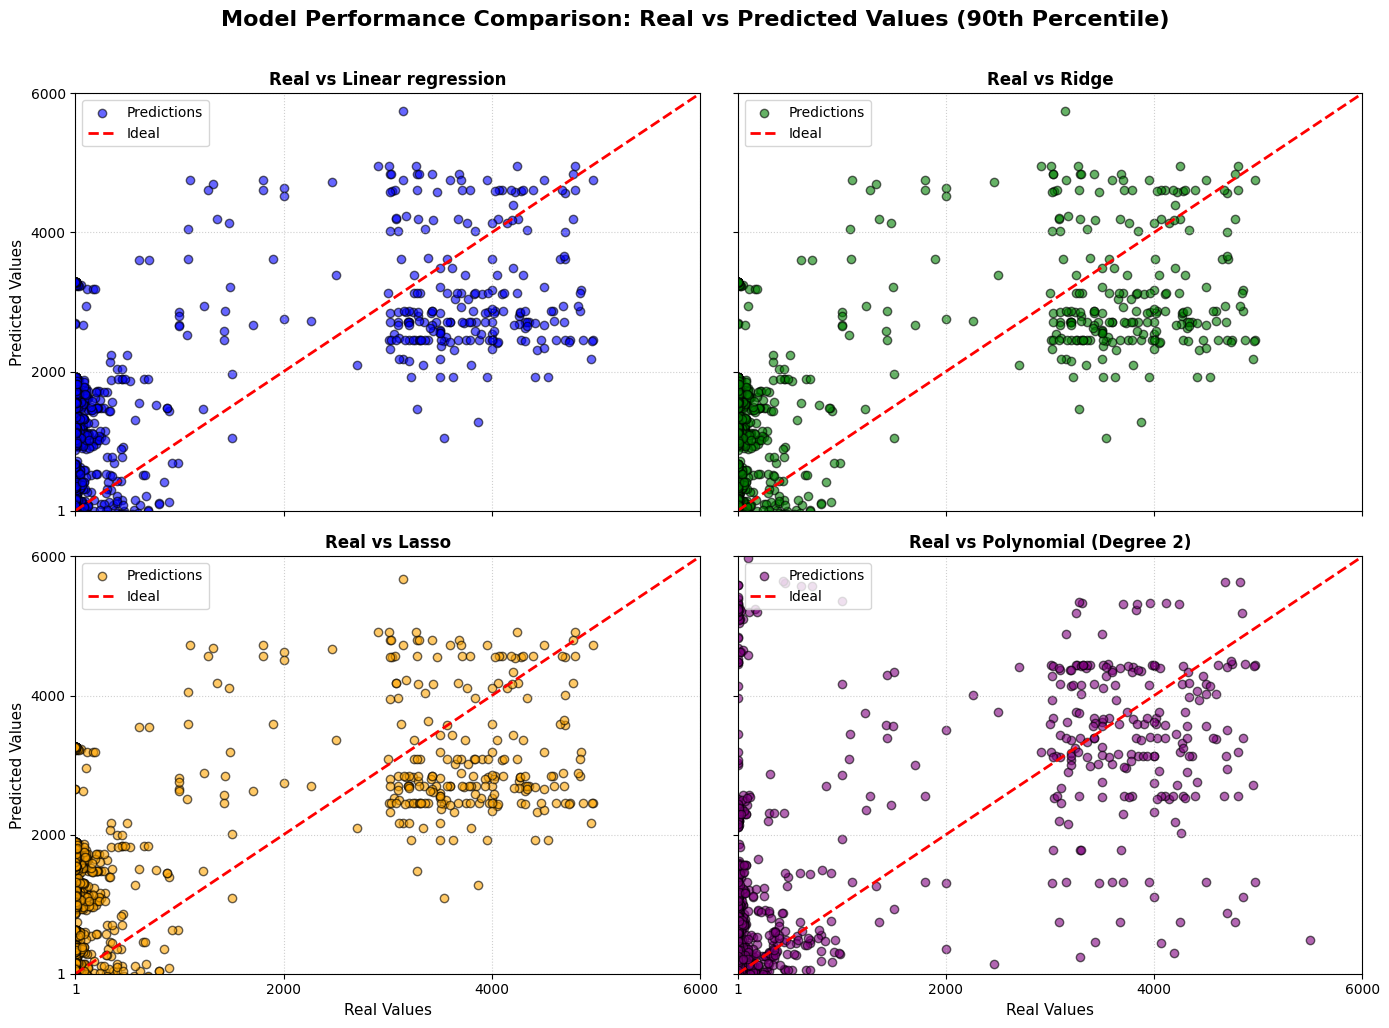

In [54]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 11), sharex=True, sharey=True)

models = [
    ("Linear regression", y_pred, "blue"),
    ("Ridge", y_pred_ridge, "green"),
    ("Lasso", y_pred_lasso, "orange"),
    (f"Polynomial (Degree {best_model})", y_pred_poly, "purple")
]

axes_flat = axes.flatten()

min_val = Y_test.min()
max_val_90 = np.percentile(Y_test, 90) 

axis_ticks = np.linspace(min_val, max_val_90, num=4)

for i, (name, predictions, color) in enumerate(models):
    ax = axes_flat[i]
    
    ax.scatter(Y_test, predictions, alpha=0.6, color=color, edgecolors='k', label='Predictions')
    
    ax.plot([min_val, max_val_90], [min_val, max_val_90], color='red', linestyle='--', linewidth=2, label='Ideal')
    
    ax.set_title(f'Real vs {name}', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')
    
    ax.set_xlim([min_val, max_val_90])
    ax.set_ylim([min_val, max_val_90])
    
    ax.set_xticks(axis_ticks)
    ax.set_yticks(axis_ticks)

for ax in axes[:, 0]:
    ax.set_ylabel('Predicted Values', fontsize=11)
for ax in axes[1, :]:
    ax.set_xlabel('Real Values', fontsize=11)

plt.suptitle('Model Performance Comparison: Real vs Predicted Values (90th Percentile)', 
             fontsize=16, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualization Note

To enhance the interpretability of the model performance comparison, the scatter plots presented in this section display **90% of the data**, corresponding to the 90th percentile of the target variable distribution. This truncation was applied to mitigate the visual distortion caused by extreme outliers and to provide a clearer view of the predictive behavior across the majority of observations. The remaining 10% of high-end values, while potentially relevant for extreme event analysis, were excluded from the graphical representation to prevent compression of the scale and loss of detail in the central concentration of data points. All reported metrics, however, are computed on the full test set to ensure statistical integrity.


### Conclusions

#### Best Performing Model

The polynomial regression model (degree 2) offers the best performance on the test set, achieving:
- R² = 0.2348 (highest among all models)
- RMSE = 17,183.95 (lowest error)
- MAE = 3,499.11 (best average prediction accuracy)

While the improvement over linear regression is modest (+0.005 R²), the polynomial model consistently outperforms all other approaches.

### Interpretation for the Problem

**Factors that increase burned area:**
- Fire class G has the strongest positive impact (largest coefficient)
- Fire class F and June also contribute significantly
- Tropical perennifolio forest vegetation is highly susceptible

**Factors that decrease burned area:**
- Desert vegetation acts as a protective factor (negative coefficient)
- Higher precipitation variables (`Prec_cont`, `Prec_pre_30`, `Prec_pre_15`) slightly reduce burned area

The polynomial regression model (degree 2) performs best, though all models show limited predictive power (R² ≈ 0.23). This suggests that burned area depends on additional factors not captured in the current dataset. Lasso successfully identified fire class G as the most critical predictor, while eliminating irrelevant variables such as December/April months and certain vegetation types.